In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import Pablo as pb
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [2]:
df = pb.cargar_dataset('listings copia.csv')
df. head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1208229396139150589,https://www.airbnb.com/rooms/1208229396139150589,2.024120e+13,08/12/24,city scrape,Two Bedroom With Sunroom in The Heart of Manly,Just minutes from Manly Beach and the vibrant ...,"Manly, nestled along Sydney's picturesque Nort...",https://a0.muscache.com/pictures/prohost-api/H...,279001183,...,4.73,4.73,4.55,PID-STRA-68560,t,194,194,0,0,4.23
1,1226551214174044599,https://www.airbnb.com/rooms/1226551214174044599,2.024120e+13,08/12/24,city scrape,Beachfront ensuite room,The apartment is tastefully renovated in a coa...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,24295514,...,4.85,5.00,4.80,PID-STRA-42703,f,2,0,2,0,6.06
2,1264833485512910590,https://www.airbnb.com/rooms/1264833485512910590,2.024120e+13,08/12/24,city scrape,Bright Queen Room - Central Location,Searching for a comfortable and inviting place...,"Ryde is a suburb of Sydney, New South Wales, A...",https://a0.muscache.com/pictures/prohost-api/H...,255319514,...,5.00,5.00,5.00,PID-STRA-47947,t,46,4,42,0,0.77
3,1264834761942196027,https://www.airbnb.com/rooms/1264834761942196027,2.024120e+13,08/12/24,city scrape,Private Double Room - Centrally located,Searching for a comfortable and inviting place...,"Ryde is a suburb of Sydney, New South Wales, A...",https://a0.muscache.com/pictures/prohost-api/H...,255319514,...,4.50,4.50,4.50,PID-STRA-47947,t,46,4,42,0,2.00
4,929853,https://www.airbnb.com/rooms/929853,2.024120e+13,08/12/24,city scrape,Modern Stylish Bondi Apartment,5 Night Long Weekend Special - $199 per night,NaN,https://a0.muscache.com/pictures/14102560/1583...,5007351,...,4.50,4.83,4.17,NaN,f,1,1,0,0,0.04


In [3]:
df = df.drop(['neighbourhood_group_cleansed', 'calendar_updated'], axis=1)
df = df.fillna(method = 'ffill')
df

/var/folders/b1/dh3v5zh509jbzst2tt2143dc0000gn/T/ipykernel_40773/4004712304.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method = 'ffill')


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1208229396139150589,https://www.airbnb.com/rooms/1208229396139150589,2.024120e+13,08/12/24,city scrape,Two Bedroom With Sunroom in The Heart of Manly,Just minutes from Manly Beach and the vibrant ...,"Manly, nestled along Sydney's picturesque Nort...",https://a0.muscache.com/pictures/prohost-api/H...,279001183,...,4.73,4.73,4.55,PID-STRA-68560,t,194,194,0,0,4.23
1,1226551214174044599,https://www.airbnb.com/rooms/1226551214174044599,2.024120e+13,08/12/24,city scrape,Beachfront ensuite room,The apartment is tastefully renovated in a coa...,"Manly, nestled along Sydney's picturesque Nort...",https://a0.muscache.com/pictures/hosting/Hosti...,24295514,...,4.85,5.00,4.80,PID-STRA-42703,f,2,0,2,0,6.06
2,1264833485512910590,https://www.airbnb.com/rooms/1264833485512910590,2.024120e+13,08/12/24,city scrape,Bright Queen Room - Central Location,Searching for a comfortable and inviting place...,"Ryde is a suburb of Sydney, New South Wales, A...",https://a0.muscache.com/pictures/prohost-api/H...,255319514,...,5.00,5.00,5.00,PID-STRA-47947,t,46,4,42,0,0.77
3,1264834761942196027,https://www.airbnb.com/rooms/1264834761942196027,2.024120e+13,08/12/24,city scrape,Private Double Room - Centrally located,Searching for a comfortable and inviting place...,"Ryde is a suburb of Sydney, New South Wales, A...",https://a0.muscache.com/pictures/prohost-api/H...,255319514,...,4.50,4.50,4.50,PID-STRA-47947,t,46,4,42,0,2.00
4,929853,https://www.airbnb.com/rooms/929853,2.024120e+13,08/12/24,city scrape,Modern Stylish Bondi Apartment,5 Night Long Weekend Special - $199 per night,"Ryde is a suburb of Sydney, New South Wales, A...",https://a0.muscache.com/pictures/14102560/1583...,5007351,...,4.50,4.83,4.17,PID-STRA-47947,f,1,1,0,0,0.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17712,1305466650690461821,https://www.airbnb.com/rooms/1305466650690461821,2.024120e+13,08/12/24,city scrape,"Studio Modern, Pyrmont ISYD",Refined architectural 1 bedroom apartment with...,Auburn is a Western Sydney suburb in the state...,https://a0.muscache.com/pictures/prohost-api/H...,7409213,...,5.00,5.00,5.00,PID-STRA-73850,t,179,179,0,0,1.00
17713,1305545916099249965,https://www.airbnb.com/rooms/1305545916099249965,2.024120e+13,08/12/24,city scrape,Designer 3 Bedroom w/ Patio,Manly Waves is a boutique hotel offering styli...,Auburn is a Western Sydney suburb in the state...,https://a0.muscache.com/pictures/miso/Hosting-...,386932887,...,5.00,5.00,5.00,Exempt,t,11,9,2,0,1.00
17714,1305547378345209569,https://www.airbnb.com/rooms/1305547378345209569,2.024120e+13,08/12/24,city scrape,Spacious Sunny Entire Unit - Chippendale Sydney,It is a cozy and modern apartment unit. The sp...,Auburn is a Western Sydney suburb in the state...,https://a0.muscache.com/pictures/miso/Hosting-...,465271405,...,5.00,5.00,5.00,PID-STRA-74341,f,10,10,0,0,1.00
17715,1305579456463125891,https://www.airbnb.com/rooms/1305579456463125891,2.024120e+13,08/12/24,city scrape,2-StoreyApt︱2BR︱Parking︱Walk-Ashfield Mall & T...,This contemporary security apartment is locate...,Auburn is a Western Sydney suburb in the state...,https://a0.muscache.com/pictures/miso/Hosting-...,565965713,...,5.00,5.00,5.00,Exempt,f,21,21,0,0,1.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17717 entries, 0 to 17716
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            17717 non-null  int64  
 1   listing_url                                   17717 non-null  object 
 2   scrape_id                                     17717 non-null  float64
 3   last_scraped                                  17717 non-null  object 
 4   source                                        17717 non-null  object 
 5   name                                          17717 non-null  object 
 6   description                                   17717 non-null  object 
 7   neighborhood_overview                         17717 non-null  object 
 8   picture_url                                   17717 non-null  object 
 9   host_id                                       17717 non-null 

In [5]:
df = pb.sustitucion_valores_atipicos(df)

Limite superior permitido 2.863779267800796e+18
Limite inferior permitido -1.7182675606148938e+18
Limite superior permitido 20241200000000.0
Limite inferior permitido 20241200000000.0
Limite superior permitido 754402615.0
Limite inferior permitido -412023849.0
Limite superior permitido 53.5
Limite inferior permitido -30.5
Limite superior permitido 81.0
Limite inferior permitido -47.0
Limite superior permitido -33.656409679999996
Limite inferior permitido -34.04123720000001
Limite superior permitido 151.43051079999998
Limite inferior permitido 150.962082
Limite superior permitido 12.0
Limite inferior permitido -4.0
Limite superior permitido 3.5
Limite inferior permitido -0.5
Limite superior permitido 3.5
Limite inferior permitido -0.5
Limite superior permitido 6.0
Limite inferior permitido -2.0
Limite superior permitido 12.0
Limite inferior permitido -4.0
Limite superior permitido 1690.0
Limite inferior permitido -870.0
Limite superior permitido 11.0
Limite inferior permitido -5.0
Limit

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17717 entries, 0 to 17716
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   listing_url                                   17717 non-null  object 
 1   last_scraped                                  17717 non-null  object 
 2   source                                        17717 non-null  object 
 3   name                                          17717 non-null  object 
 4   description                                   17717 non-null  object 
 5   neighborhood_overview                         17717 non-null  object 
 6   picture_url                                   17717 non-null  object 
 7   host_url                                      17717 non-null  object 
 8   host_name                                     17717 non-null  object 
 9   host_since                                    17717 non-null 

In [6]:
listings_limpio = df.to_csv('Sydney_limpio.csv')

In [16]:
df_filtrado = df[['host_response_rate', 'host_acceptance_rate', 'host_total_listings_count', 'accommodates', 'reviews_per_month', 'price']].replace('[\$, %]', '', regex=True).astype(float)
df_filtrado = df_filtrado.dropna()
df_filtrado["host_response_rate"] = df_filtrado["host_response_rate"] / 100
df_filtrado["host_acceptance_rate"] = df_filtrado["host_acceptance_rate"] / 100
df = df.fillna(method = 'bfill')
x = df_filtrado['host_response_rate'].values
y = df_filtrado['host_acceptance_rate'].values

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/var/folders/b1/dh3v5zh509jbzst2tt2143dc0000gn/T/ipykernel_40773/2356585041.py:1: SyntaxWarning: invalid escape sequence '\$'
  df_filtrado = df[['host_response_rate', 'host_acceptance_rate', 'host_total_listings_count', 'accommodates', 'reviews_per_month', 'price']].replace('[\$, %]', '', regex=True).astype(float)
/var/folders/b1/dh3v5zh509jbzst2tt2143dc0000gn/T/ipykernel_40773/2356585041.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method = 'bfill')


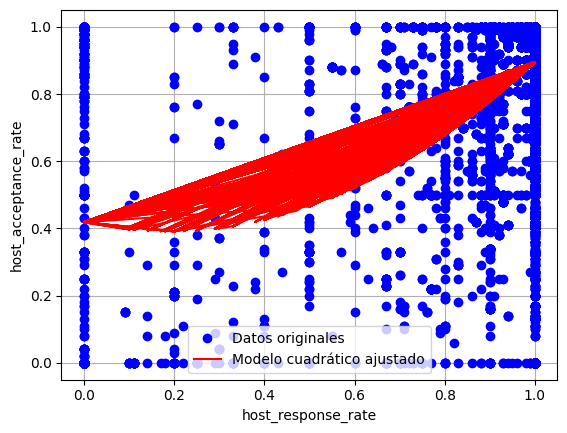

Parámetros ajustados: [ 0.76575849 -0.28882955  0.41810485]
R² del modelo: 0.18778344363323407
R del modelo: 0.43333987080954606
R del Modelo 1: 0.43333987080954606


In [ ]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["host_acceptance_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_response_rate")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

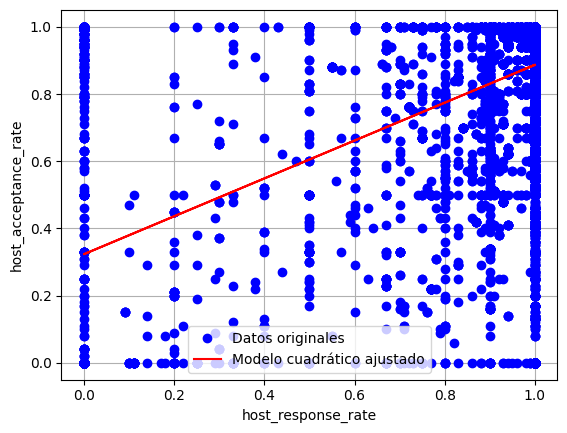

Parámetros ajustados: [-123.6484526   124.21193127    0.32325967]
R² del modelo: 0.16962129046532126
R del modelo: 0.41185105373826747
R del Modelo 1: 0.41185105373826747


In [ ]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["host_acceptance_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_response_rate")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

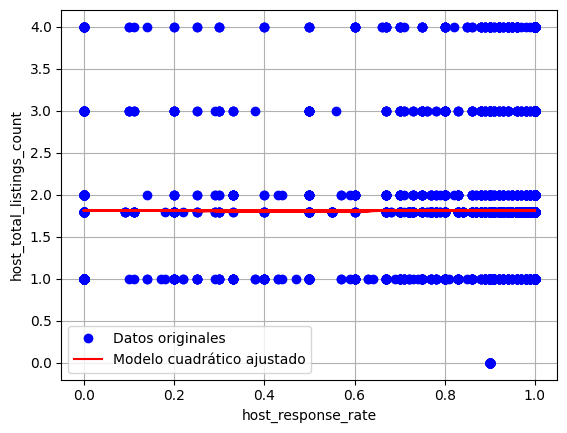

Parámetros ajustados: [ 0.0237909  -0.02115736  1.81080664]
R² del modelo: 3.686333377328488e-06
R del modelo: 0.0019199826502675715
R del Modelo 1: 0.0019199826502675715


In [19]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["host_total_listings_count"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_response_rate")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

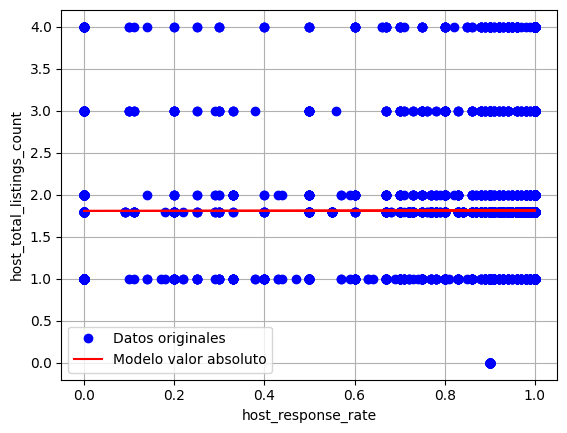

Parámetros ajustados: [-123.92752044  123.93284293    1.80785994]
R² del modelo: 1.707914784265796e-06
R del modelo: 0.0013068721376882269
R del Modelo 1: 0.0013068721376882269


In [20]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["host_total_listings_count"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_response_rate")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

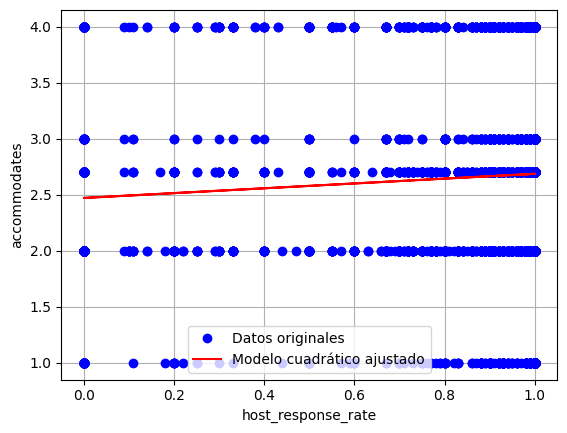

Parámetros ajustados: [-123.82236553  124.03799784    2.47169433]
R² del modelo: 0.0020476257504187245
R del modelo: 0.04525069889425714
R del Modelo 1: 0.04525069889425714


In [ ]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["accommodates"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_response_rate")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

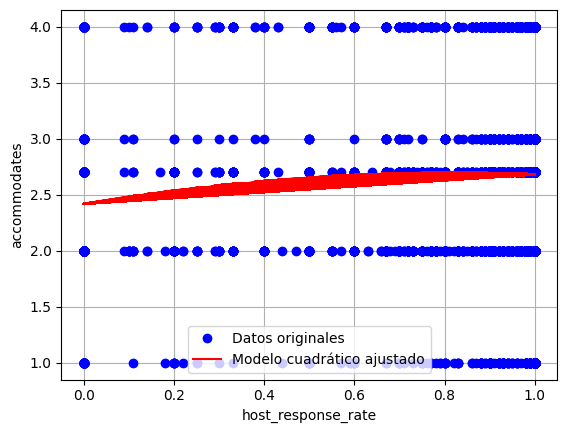

Parámetros ajustados: [-0.41749419  0.68031348  2.41998429]
R² del modelo: 0.0024926513244721837
R del modelo: 0.04992645916217355
R del Modelo 1: 0.04992645916217355


In [18]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["accommodates"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_response_rate")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

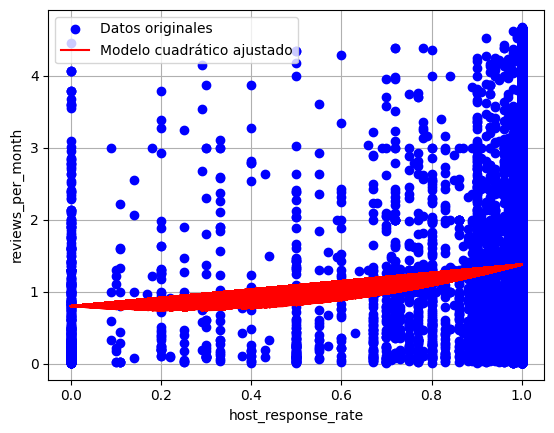

Parámetros ajustados: [ 1.09827041 -0.51993013  0.79773207]
R² del modelo: 0.0153175930939774
R del modelo: 0.12376426420408033
R del Modelo 1: 0.12376426420408033


In [21]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["reviews_per_month"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_response_rate")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

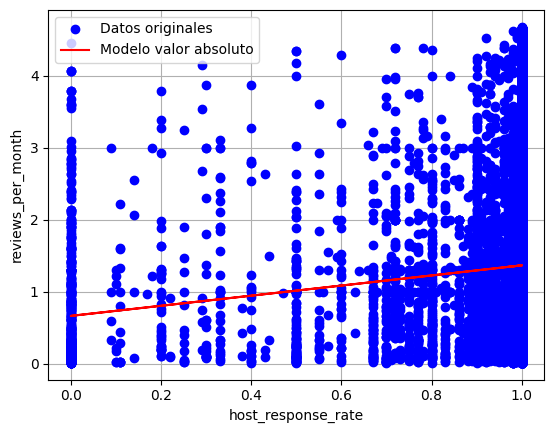

Parámetros ajustados: [ 124.28141744 -123.57894593    0.66170234]
R² del modelo: 0.0134162774949248
R del modelo: 0.11582865575894766
R del Modelo 1: 0.11582865575894766


In [22]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["reviews_per_month"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_response_rate")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

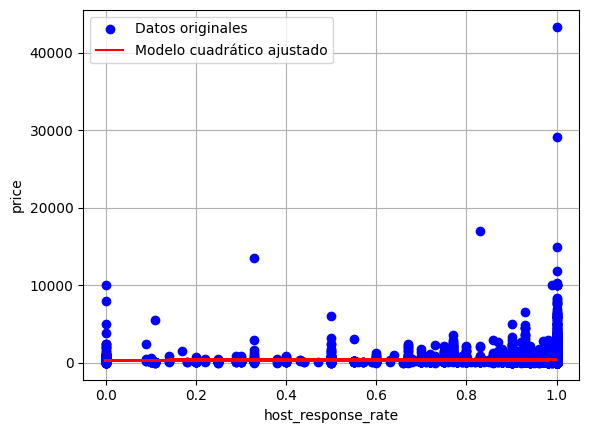

Parámetros ajustados: [-486.25635442  553.16840783  314.98166669]
R² del modelo: 0.000868120549899376
R del modelo: 0.029463885519384166
R del Modelo 1: 0.029463885519384166


In [23]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["price"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_response_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

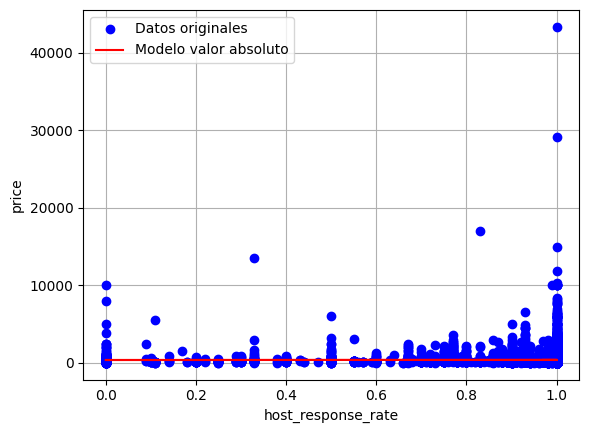

Parámetros ajustados: [ 176.66457153 -164.71146162  375.20861581]
R² del modelo: 8.954945549977111e-06
R del modelo: 0.0029924815036984124
R del Modelo 1: 0.0029924815036984124


In [24]:
x = df_filtrado["host_response_rate"].values
y = df_filtrado["price"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_response_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

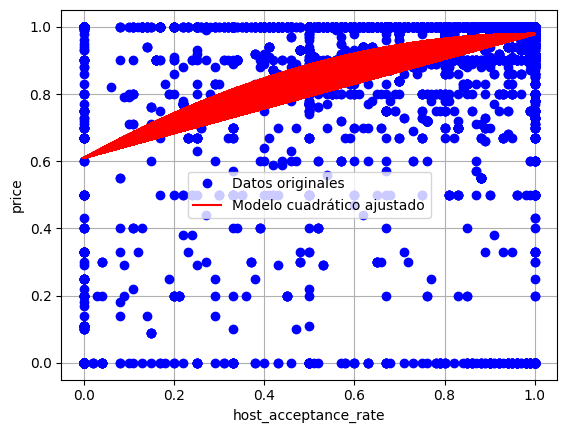

Parámetros ajustados: [-0.3699792   0.73839589  0.61008153]
R² del modelo: 0.19110375472904528
R del modelo: 0.43715415442272226
R del Modelo 1: 0.43715415442272226


In [25]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["host_response_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_acceptance_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

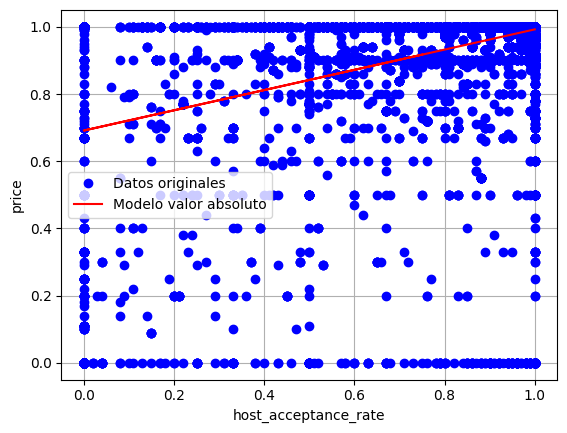

Parámetros ajustados: [ 127.76747833 -127.46645614    0.69121433]
R² del modelo: 0.16962102254680933
R del modelo: 0.4118507284767253
R del Modelo 1: 0.4118507284767253


In [26]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["host_response_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_acceptance_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

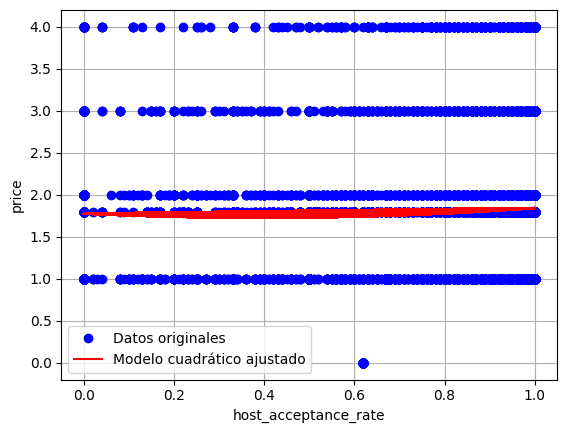

Parámetros ajustados: [ 0.31534619 -0.24821867  1.77514246]
R² del modelo: 0.0026921535608807057
R del modelo: 0.05188596689742522
R del Modelo 1: 0.05188596689742522


In [27]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["host_total_listings_count"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_acceptance_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

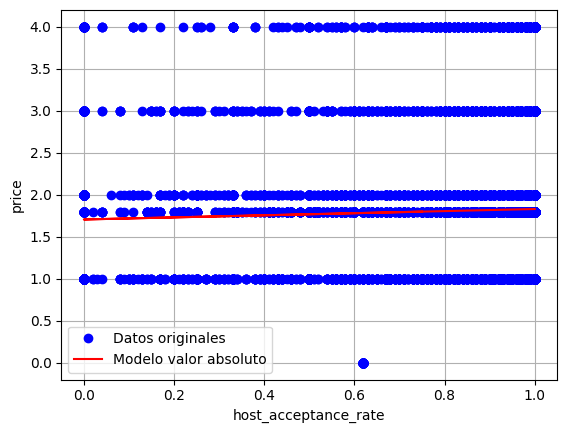

Parámetros ajustados: [-127.55468213  127.67925234    1.70599013]
R² del modelo: 0.0017512470542832004
R del modelo: 0.04184790382185469
R del Modelo 1: 0.04184790382185469


In [28]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["host_total_listings_count"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_acceptance_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

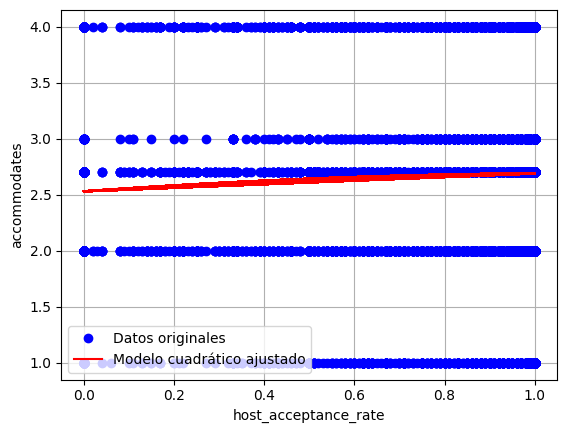

Parámetros ajustados: [-0.12758329  0.28760548  2.53107402]
R² del modelo: 0.0016547775391085873
R del modelo: 0.04067895695698929
R del Modelo 1: 0.04067895695698929


In [29]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["accommodates"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_acceptance_rate")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

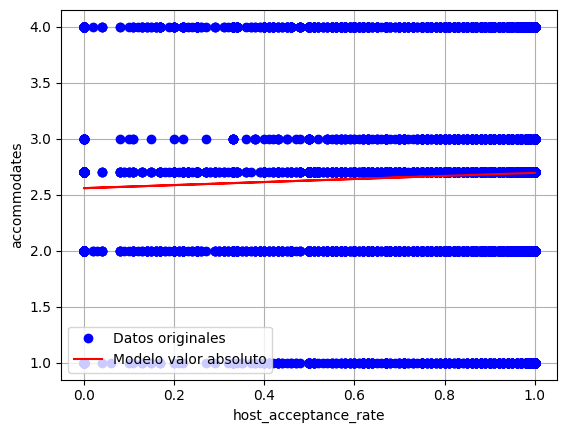

Parámetros ajustados: [-127.54857627  127.6853582     2.55905177]
R² del modelo: 0.001542279322171325
R del modelo: 0.0392718642563773
R del Modelo 1: 0.0392718642563773


In [30]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["accommodates"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_acceptance_rate")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

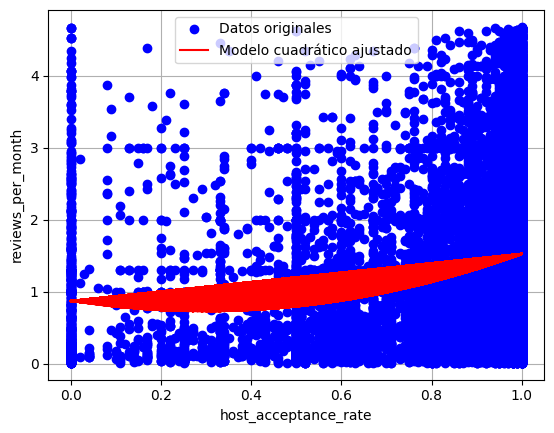

Parámetros ajustados: [ 1.61153209 -0.95749929  0.86880495]
R² del modelo: 0.05677888853581459
R del modelo: 0.23828321077200254
R del Modelo 1: 0.23828321077200254


In [31]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["reviews_per_month"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_acceptance_rate")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

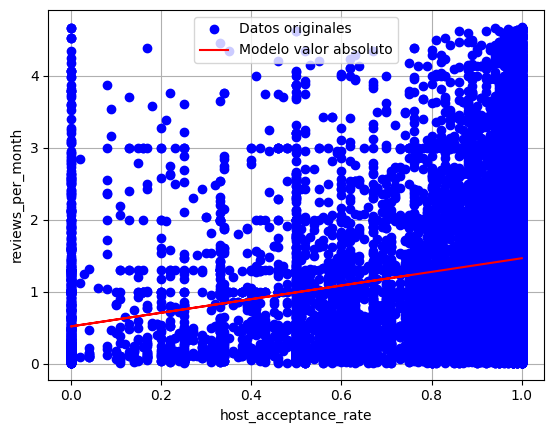

Parámetros ajustados: [ 128.09076    -127.14317447    0.51541181]
R² del modelo: 0.045697673515377124
R del modelo: 0.21377014177704315
R del Modelo 1: 0.21377014177704315


In [32]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["reviews_per_month"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_acceptance_rate")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

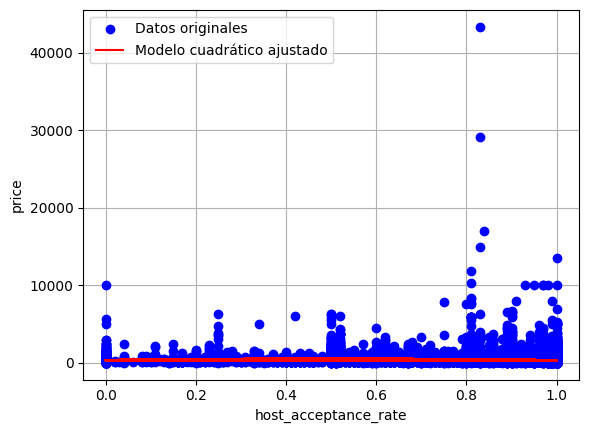

Parámetros ajustados: [-725.00943358  707.79050994  355.70947476]
R² del modelo: 0.007784759821264475
R del modelo: 0.0882312859549518
R del Modelo 1: 0.0882312859549518


In [33]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["price"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_acceptance_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

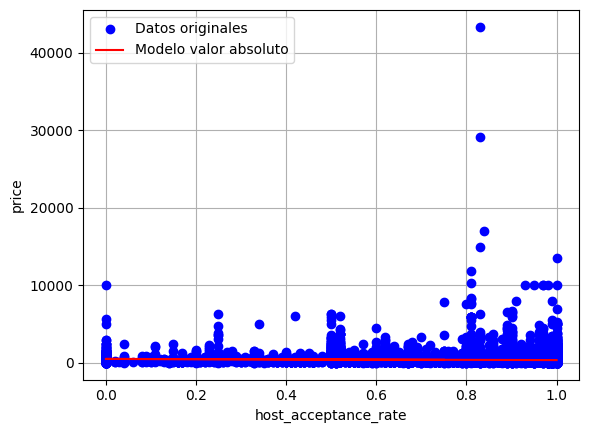

Parámetros ajustados: [-600.76377439  451.47952317  514.69636767]
R² del modelo: 0.002614561985498476
R del modelo: 0.051132787773584924
R del Modelo 1: 0.051132787773584924


In [34]:
x = df_filtrado["host_acceptance_rate"].values
y = df_filtrado["price"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_acceptance_rate")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

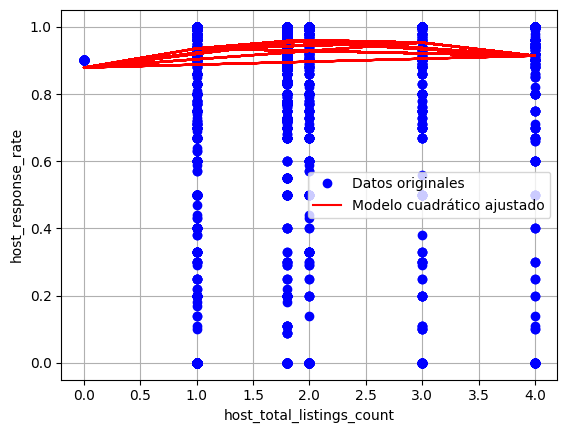

Parámetros ajustados: [-0.01599492  0.07276059  0.87856888]
R² del modelo: 0.00582088541710879
R del modelo: 0.07629472732180638
R del Modelo 1: 0.07629472732180638


In [35]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["host_response_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_total_listings_count")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

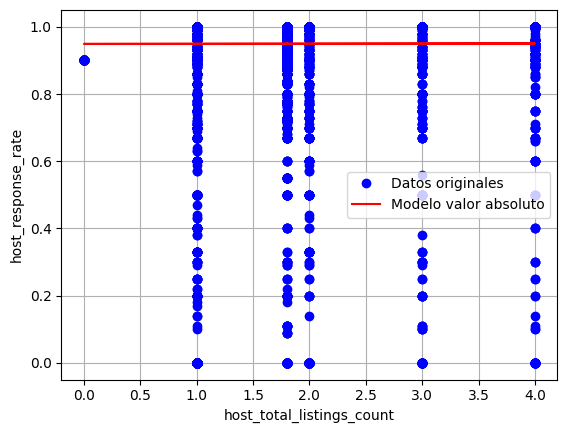

Parámetros ajustados: [ 106.36548544 -106.36516455    0.94901301]
R² del modelo: 1.7079147894838442e-06
R del modelo: 0.0013068721396846152
R del Modelo 1: 0.0013068721396846152


In [36]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["host_response_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_total_listings_count")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

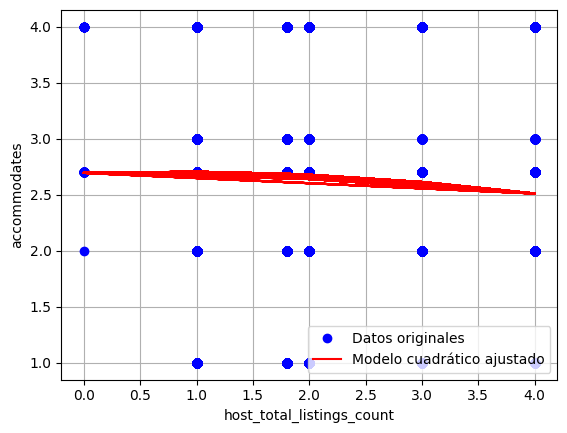

Parámetros ajustados: [-0.01874088  0.02887536  2.69544412]
R² del modelo: 0.002642519886596917
R del modelo: 0.051405446079155044
R del Modelo 1: 0.051405446079155044


In [37]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["accommodates"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_total_listings_count")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

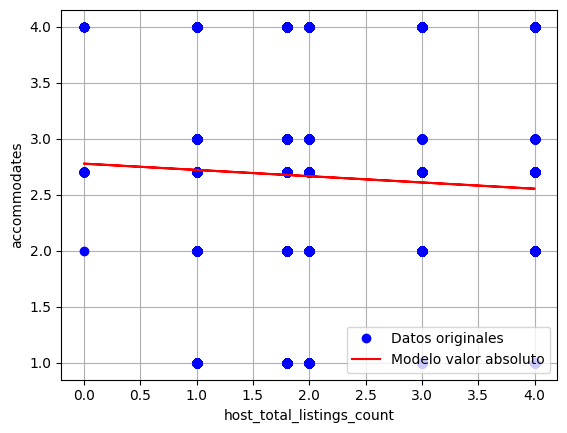

Parámetros ajustados: [-106.39332528  106.33732471    2.77798187]
R² del modelo: 0.0022907165486429903
R del modelo: 0.04786143069991734
R del Modelo 1: 0.04786143069991734


In [38]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["accommodates"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_total_listings_count")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

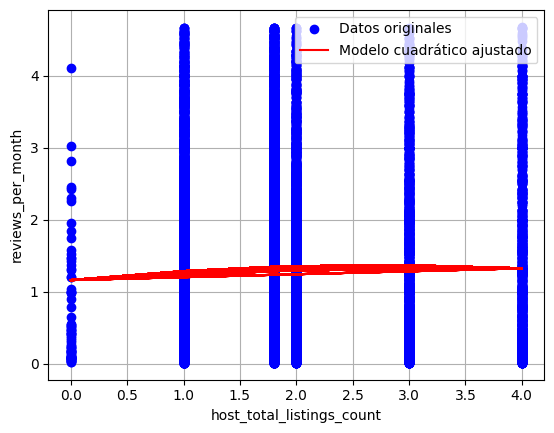

Parámetros ajustados: [-0.02775451  0.1518046   1.15920126]
R² del modelo: 0.0007837194732978059
R del modelo: 0.027994990146413802
R del Modelo 1: 0.027994990146413802


In [39]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["reviews_per_month"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_total_listings_count")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

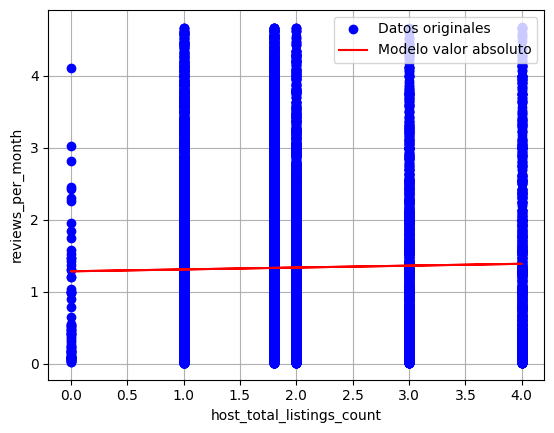

Parámetros ajustados: [ 106.37837834 -106.35227166    1.28143644]
R² del modelo: 0.0003073558136665877
R del modelo: 0.01753156620689058
R del Modelo 1: 0.01753156620689058


In [40]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["reviews_per_month"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_total_listings_count")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

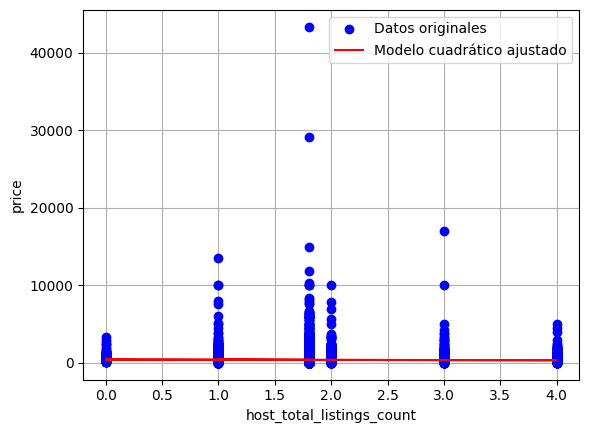

Parámetros ajustados: [  2.19807848 -31.84265389 435.92050413]
R² del modelo: 0.0005049095567501993
R del modelo: 0.022470192628239734
R del Modelo 1: 0.022470192628239734


In [41]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["price"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("host_total_listings_count")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

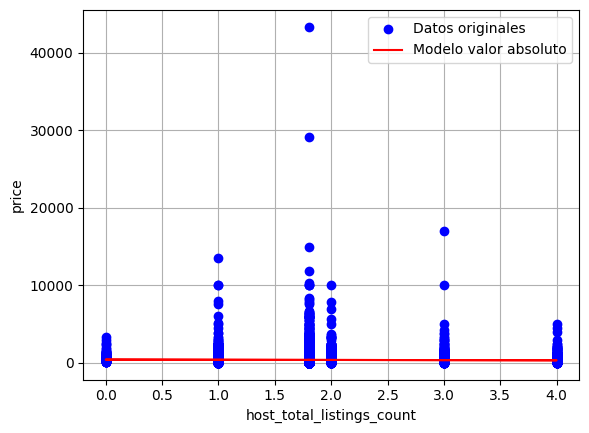

Parámetros ajustados: [ 213.14571276 -235.03350906  426.23993168]
R² del modelo: 0.0004980246438709424
R del modelo: 0.022316465756721925
R del Modelo 1: 0.022316465756721925


In [42]:
x = df_filtrado["host_total_listings_count"].values
y = df_filtrado["price"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("host_total_listings_count")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

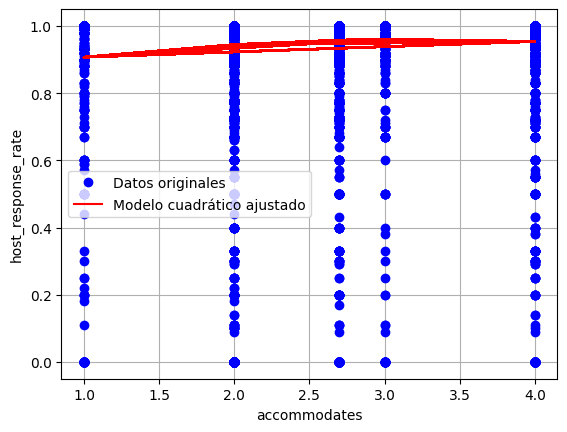

Parámetros ajustados: [-0.0108678   0.06994167  0.84798218]
R² del modelo: 0.004560238458411803
R del modelo: 0.06752953767361215
R del Modelo 1: 0.06752953767361215


In [43]:
x = df_filtrado["accommodates"].values
y = df_filtrado["host_response_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("accommodates")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

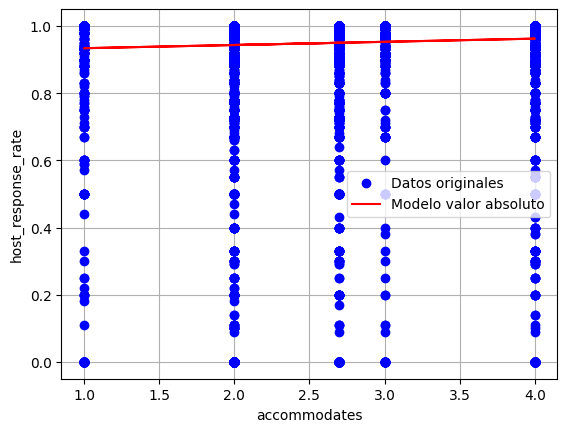

Parámetros ajustados: [ 103.13051971 -103.1210238     0.92417932]
R² del modelo: 0.0020476257504231654
R del modelo: 0.04525069889430621
R del Modelo 1: 0.04525069889430621


In [44]:
x = df_filtrado["accommodates"].values
y = df_filtrado["host_response_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("accommodates")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

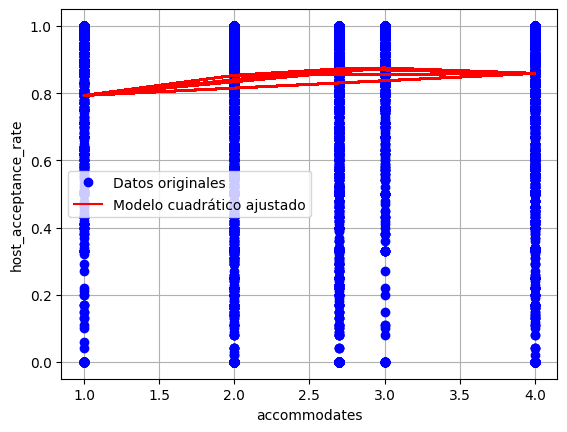

Parámetros ajustados: [-0.01894341  0.11663702  0.69534768]
R² del modelo: 0.005620532606002593
R del modelo: 0.07497021145763558
R del Modelo 1: 0.07497021145763558


In [45]:
x = df_filtrado["accommodates"].values
y = df_filtrado["host_acceptance_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("accommodates")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

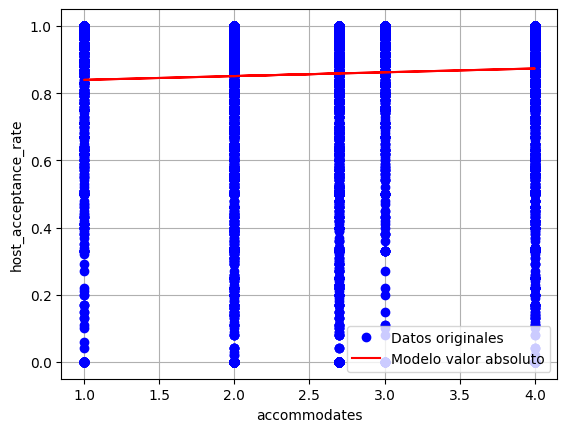

Parámetros ajustados: [-103.12013403  103.13140949    0.8281651 ]
R² del modelo: 0.0015422793221684383
R del modelo: 0.03927186425634055
R del Modelo 1: 0.03927186425634055


In [46]:
x = df_filtrado["accommodates"].values
y = df_filtrado["host_acceptance_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("accommodates")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

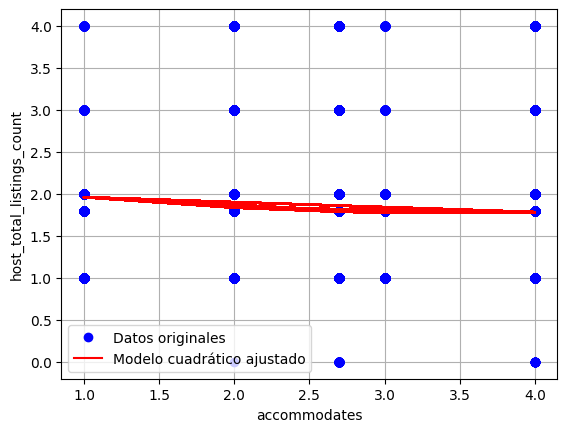

Parámetros ajustados: [ 0.03257945 -0.22210929  2.1508187 ]
R² del modelo: 0.0036520425371259213
R del modelo: 0.060432131661277026
R del Modelo 1: 0.060432131661277026


In [47]:
x = df_filtrado["accommodates"].values
y = df_filtrado["host_total_listings_count"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("accommodates")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

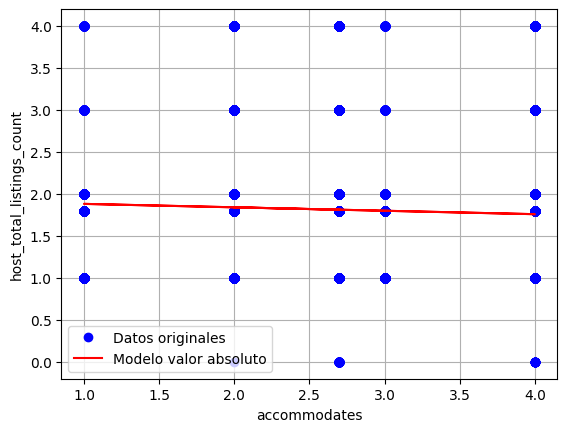

Parámetros ajustados: [-103.14622438  103.10531914    1.92239528]
R² del modelo: 0.0022907165486433234
R del modelo: 0.047861430699920826
R del Modelo 1: 0.047861430699920826


In [48]:
x = df_filtrado["accommodates"].values
y = df_filtrado["host_total_listings_count"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("accommodates")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

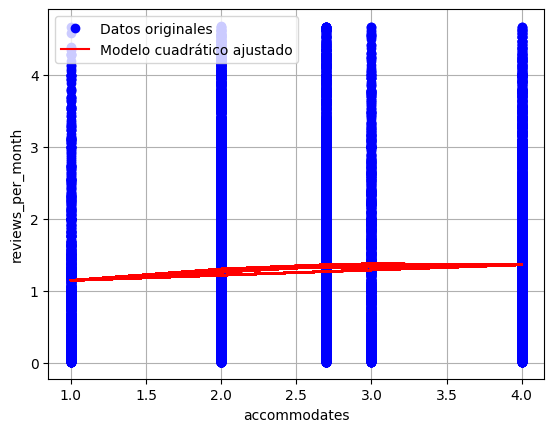

Parámetros ajustados: [-0.0427092   0.2861622   0.89919736]
R² del modelo: 0.0025142786368186343
R del modelo: 0.05014258306887106
R del Modelo 1: 0.05014258306887106


In [49]:
x = df_filtrado["accommodates"].values
y = df_filtrado["reviews_per_month"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("accommodates")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

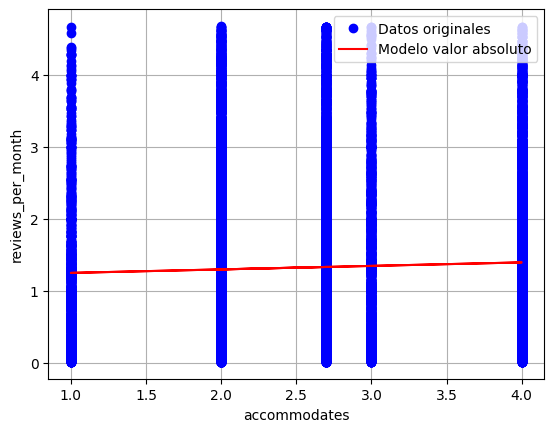

Parámetros ajustados: [ 103.15008045 -103.10146307    1.19864323]
R² del modelo: 0.0014592669647802703
R del modelo: 0.038200352940519676
R del Modelo 1: 0.038200352940519676


In [50]:
x = df_filtrado["accommodates"].values
y = df_filtrado["reviews_per_month"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("accommodates")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

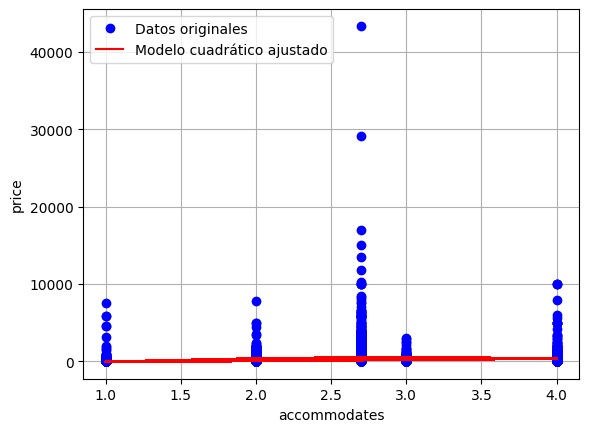

Parámetros ajustados: [-139.96028995  847.6099132  -779.85272548]
R² del modelo: 0.03292553066824666
R del modelo: 0.1814539353892515
R del Modelo 1: 0.1814539353892515


In [51]:
x = df_filtrado["accommodates"].values
y = df_filtrado["price"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("accommodates")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

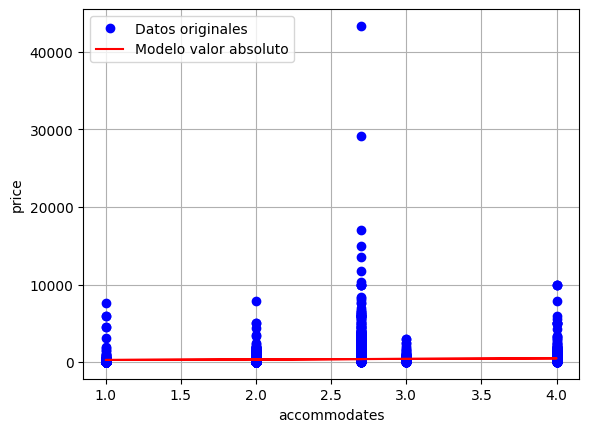

Parámetros ajustados: [-89.16075875 158.32391778 201.44697857]
R² del modelo: 0.0068078730305113355
R del modelo: 0.08250983596221323
R del Modelo 1: 0.08250983596221323


In [52]:
x = df_filtrado["accommodates"].values
y = df_filtrado["price"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("accommodates")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

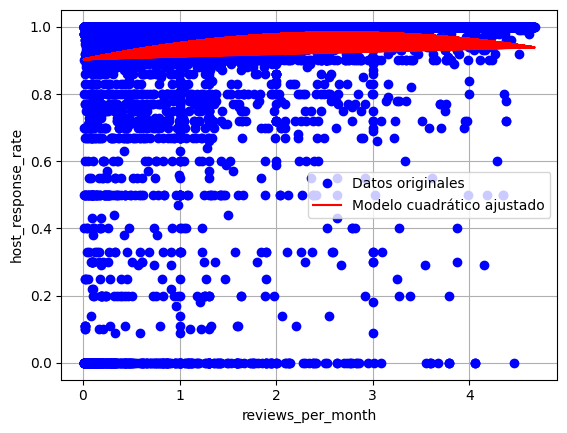

Parámetros ajustados: [-0.01120443  0.06017845  0.90232743]
R² del modelo: 0.02065332010343013
R del modelo: 0.14371263028498965
R del Modelo 1: 0.14371263028498965


In [53]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_response_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("reviews_per_month")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

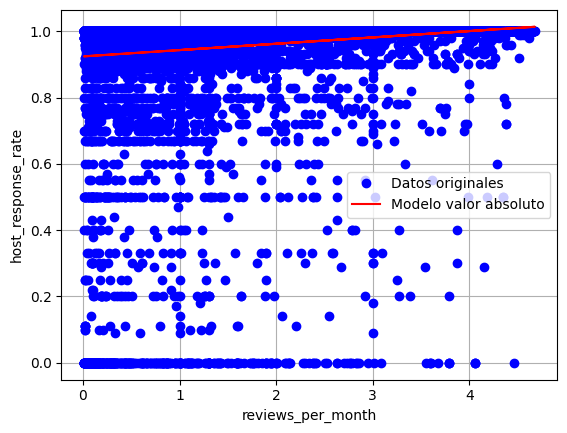

Parámetros ajustados: [-108.2190927   108.23819138    0.92421707]
R² del modelo: 0.01341627749492591
R del modelo: 0.11582865575895246
R del Modelo 1: 0.11582865575895246


In [54]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_response_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("reviews_per_month")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

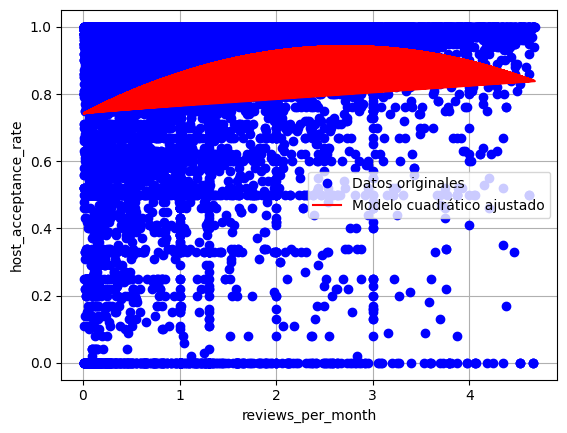

Parámetros ajustados: [-0.02713814  0.14772426  0.74124449]
R² del modelo: 0.06837849501646043
R del modelo: 0.26149282020059444
R del Modelo 1: 0.26149282020059444


In [55]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_acceptance_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("reviews_per_month")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

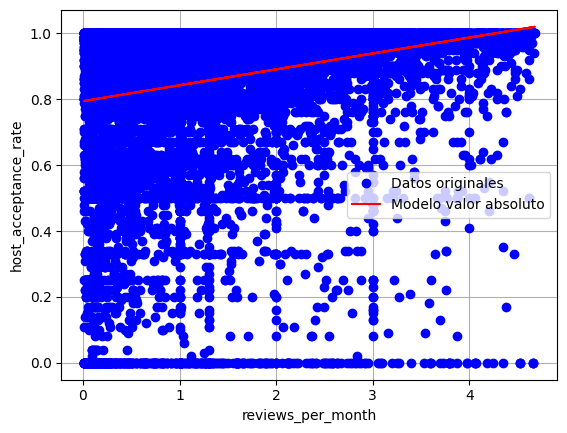

Parámetros ajustados: [ 108.25275473 -108.20452935    0.79426317]
R² del modelo: 0.04569767351537701
R del modelo: 0.21377014177704287
R del Modelo 1: 0.21377014177704287


In [56]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_acceptance_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("reviews_per_month")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

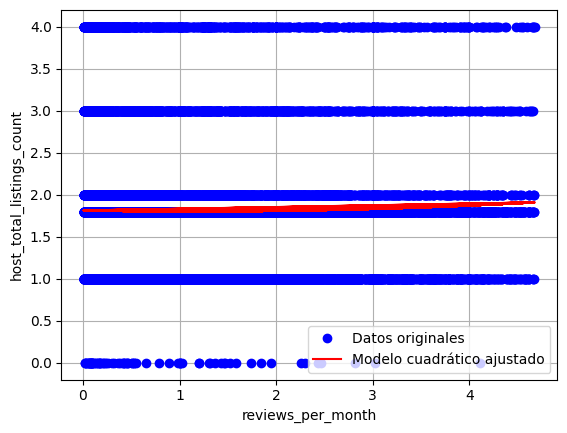

Parámetros ajustados: [ 0.00847939 -0.01931565  1.81383634]
R² del modelo: 0.000557244967862025
R del modelo: 0.023606036682637454
R del Modelo 1: 0.023606036682637454


In [57]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_total_listings_count"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("reviews_per_month")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

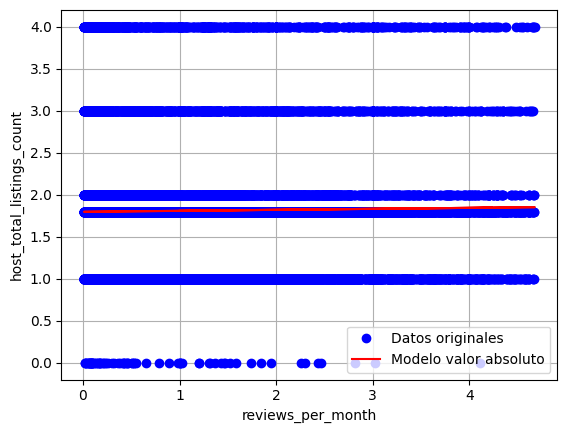

Parámetros ajustados: [-108.2227555   108.23452857    1.7972705 ]
R² del modelo: 0.00030735581366680975
R del modelo: 0.01753156620689691
R del Modelo 1: 0.01753156620689691


In [58]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_total_listings_count"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("reviews_per_month")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

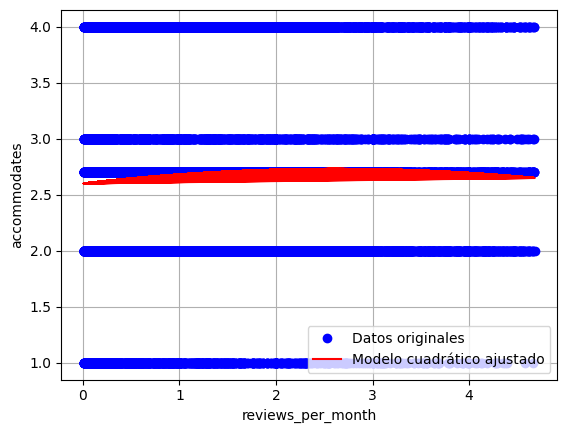

Parámetros ajustados: [-0.01899679  0.0996649   2.59946103]
R² del modelo: 0.0023754128849500233
R del modelo: 0.048738207650159064
R del Modelo 1: 0.048738207650159064


In [59]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["accommodates"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("reviews_per_month")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

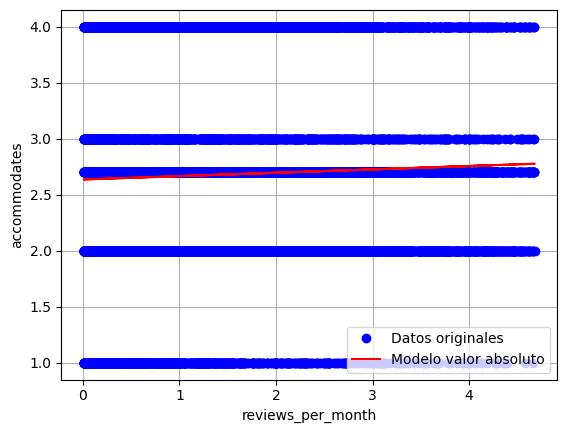

Parámetros ajustados: [-108.21363437  108.2436497     2.63657429]
R² del modelo: 0.0014592669647802703
R del modelo: 0.038200352940519676
R del Modelo 1: 0.038200352940519676


In [60]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["accommodates"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("reviews_per_month")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

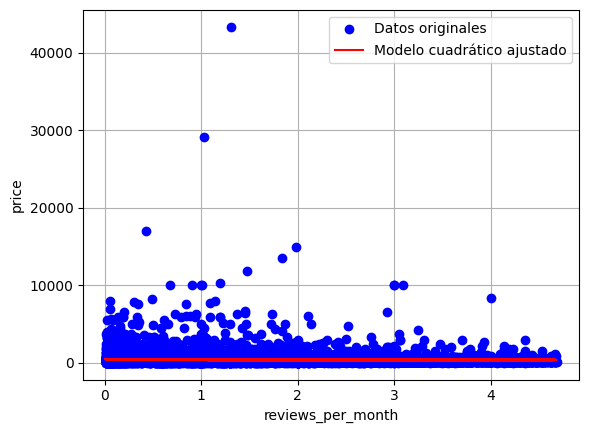

Parámetros ajustados: [  24.28934427 -139.7713273   501.40363664]
R² del modelo: 0.008061100340208793
R del modelo: 0.08978363069184045
R del Modelo 1: 0.08978363069184045


In [61]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["price"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("reviews_per_month")
plt.ylabel("price")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

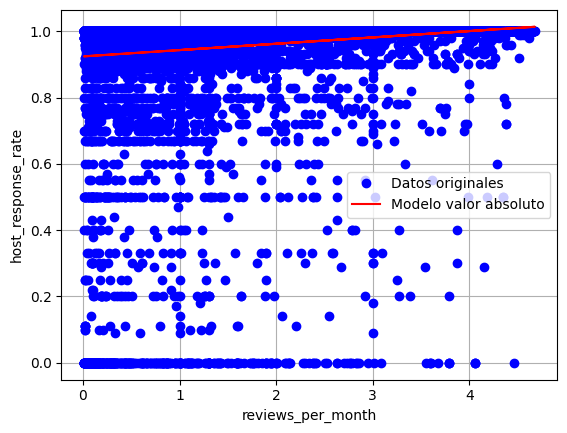

Parámetros ajustados: [-108.2190927   108.23819138    0.92421707]
R² del modelo: 0.01341627749492591
R del modelo: 0.11582865575895246
R del Modelo 1: 0.11582865575895246


In [62]:
x = df_filtrado["reviews_per_month"].values
y = df_filtrado["host_response_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("reviews_per_month")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

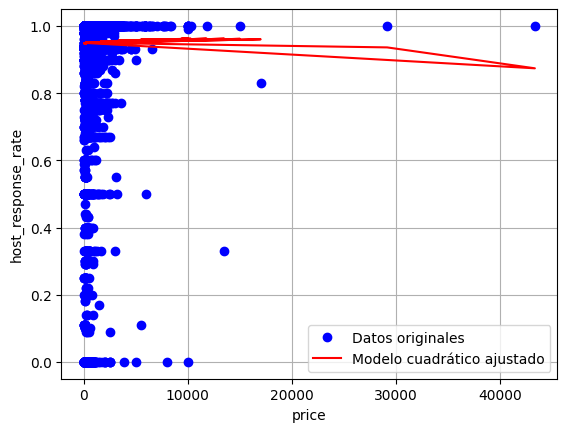

Parámetros ajustados: [-9.10465371e-11  2.21880790e-06  9.48796162e-01]
R² del modelo: 4.3408770727504375e-05
R del modelo: 0.006588533275889587
R del Modelo 1: 0.006588533275889587


In [63]:
x = df_filtrado["price"].values
y = df_filtrado["host_response_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("price")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

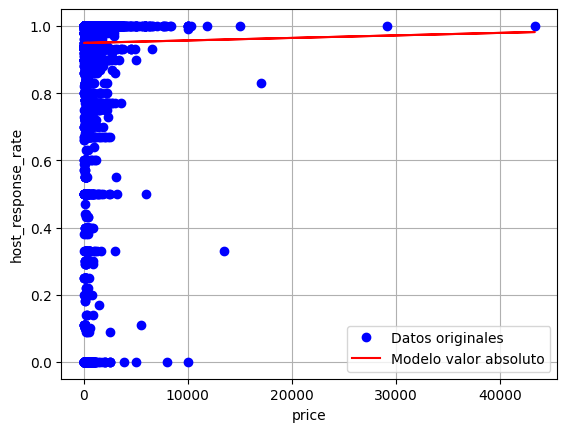

Parámetros ajustados: [-100.00003812  100.00003887    0.94930515]
R² del modelo: 8.95494511643502e-06
R del modelo: 0.0029924814312598533
R del Modelo 1: 0.0029924814312598533


In [65]:
x = df_filtrado["price"].values
y = df_filtrado["host_response_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("price")
plt.ylabel("host_response_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

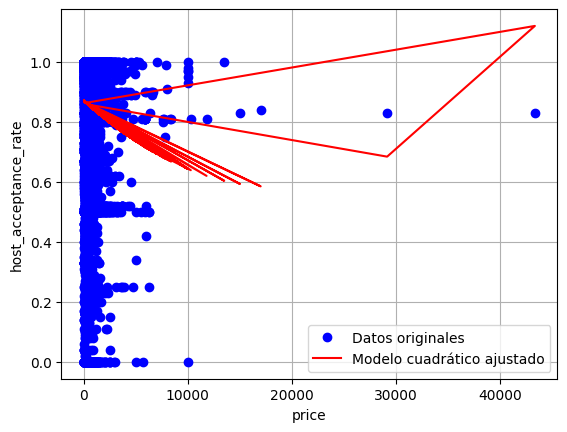

Parámetros ajustados: [ 8.54405886e-10 -3.13055004e-05  8.69889997e-01]
R² del modelo: 0.004235462442943483
R del modelo: 0.06508043056820909
R del Modelo 1: 0.06508043056820909


In [66]:
x = df_filtrado["price"].values
y = df_filtrado["host_acceptance_rate"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("price")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

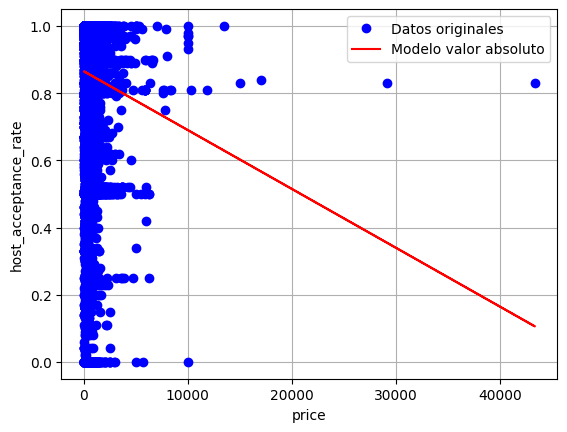

Parámetros ajustados: [-100.00004726  100.00002974    0.86511356]
R² del modelo: 0.00261456198462906
R del modelo: 0.05113278776508338
R del Modelo 1: 0.05113278776508338


In [67]:
x = df_filtrado["price"].values
y = df_filtrado["host_acceptance_rate"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("price")
plt.ylabel("host_acceptance_rate")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

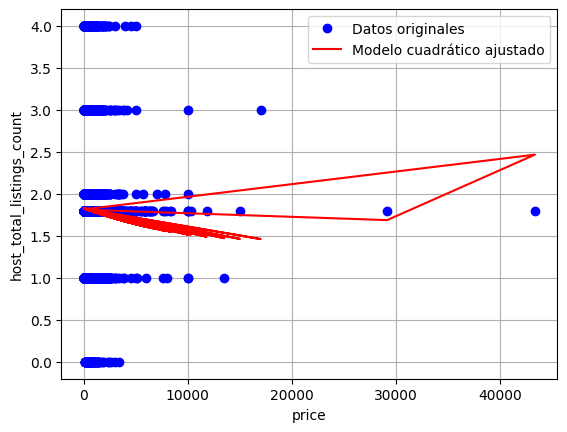

Parámetros ajustados: [ 1.37661430e-09 -4.49745053e-05  1.82940552e+00]
R² del modelo: 0.0009728912441321347
R del modelo: 0.031191204595721125
R del Modelo 1: 0.031191204595721125


In [68]:
x = df_filtrado["price"].values
y = df_filtrado["host_total_listings_count"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("price")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

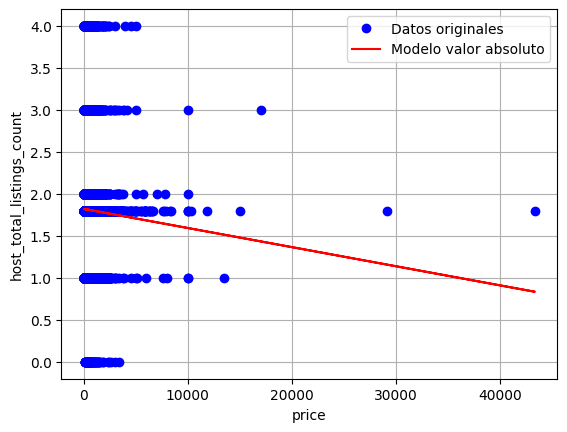

Parámetros ajustados: [-100.00004988  100.00002712    1.82170975]
R² del modelo: 0.0004980246440252634
R del modelo: 0.022316465760179486
R del Modelo 1: 0.022316465760179486


In [69]:
x = df_filtrado["price"].values
y = df_filtrado["host_total_listings_count"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("price")
plt.ylabel("host_total_listings_count")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

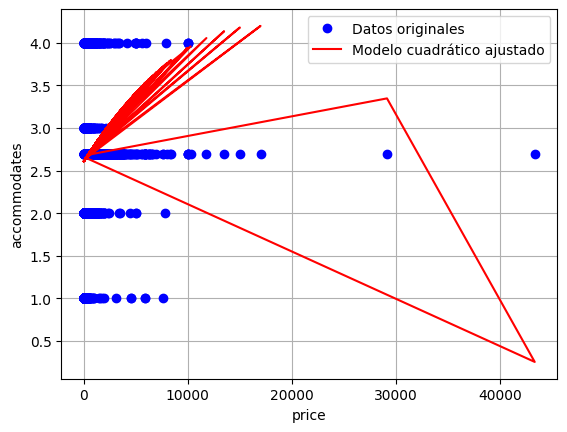

Parámetros ajustados: [-5.61119976e-09  1.89006538e-04  2.60703921e+00]
R² del modelo: 0.012570824802607738
R del modelo: 0.1121196896294658
R del Modelo 1: 0.1121196896294658


In [70]:
x = df_filtrado["price"].values
y = df_filtrado["accommodates"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("price")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

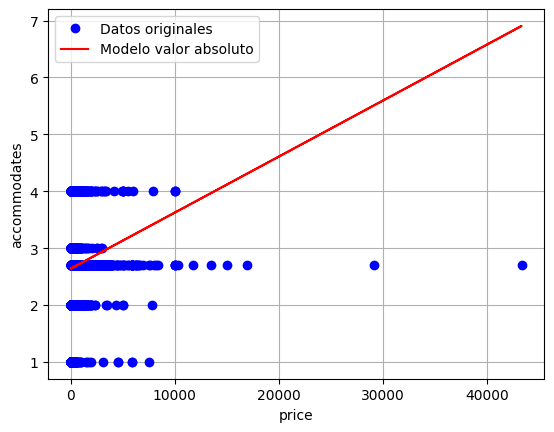

Parámetros ajustados: [100.00008771 -99.99998928   2.63840781]
R² del modelo: 0.0068078730303715584
R del modelo: 0.0825098359613662
R del Modelo 1: 0.0825098359613662


In [71]:
x = df_filtrado["price"].values
y = df_filtrado["accommodates"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("price")
plt.ylabel("accommodates")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

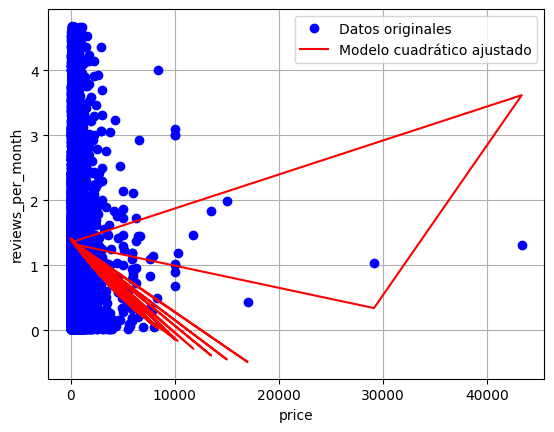

Parámetros ajustados: [ 6.16590099e-09 -2.16442049e-04  1.40842926e+00]
R² del modelo: 0.010225678330607169
R del modelo: 0.10112209615414017
R del Modelo 1: 0.10112209615414017


In [73]:
x = df_filtrado["price"].values
y = df_filtrado["reviews_per_month"].values
def func_cuadratica(x, a, b, c):
    return a * x**2 + b * x + c


parametros1, covs = curve_fit(func_cuadratica, x, y)


y_pred1 = func_cuadratica(x, *parametros1)


plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo cuadrático ajustado")
plt.xlabel("price")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()


R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R) 

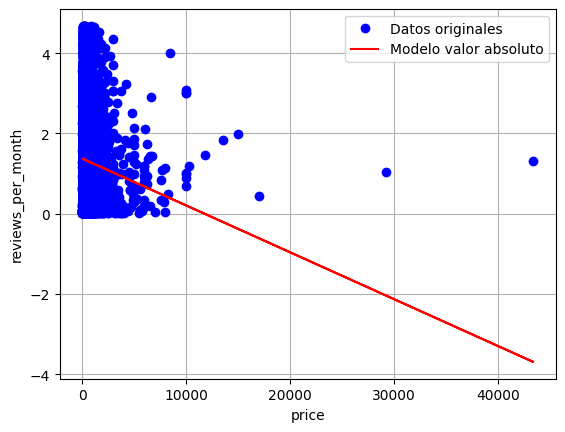

Parámetros ajustados: [-100.00009696   99.99998004    1.37395969]
R² del modelo: 0.005929540063782879
R del modelo: 0.07700350682782492
R del Modelo 1: 0.07700350682782492


In [72]:
x = df_filtrado["price"].values
y = df_filtrado["reviews_per_month"].values

def func_valor_absoluto(x, a, b, c):  
    return a * np.abs(x) + b * x + c 


parametros1, covs = curve_fit(func_valor_absoluto, x, y)

y_pred1 = func_valor_absoluto(x, *parametros1)

plt.plot(x, y, 'bo', label="Datos originales")
plt.plot(x, y_pred1, 'r-', label="Modelo valor absoluto")
plt.xlabel("price")
plt.ylabel("reviews_per_month")
plt.legend()
plt.grid(True)
plt.show()

R2_Modelo1 = r2_score(y, y_pred1)
R = np.sqrt(R2_Modelo1)
print("Parámetros ajustados:", parametros1)
print("R² del modelo:", R2_Modelo1)
print("R del modelo:", R)
print("R del Modelo 1:", R)  

In [3]:
resultados = [
    {"Variable objetivo": "host_acceptance_rate", "Modelo": "Cuadrático", "R²": 0.187783, "R": 0.43334},
    {"Variable objetivo": "host_acceptance_rate", "Modelo": "Valor absoluto", "R²": 0.169621, "R": 0.41185},
    {"Variable objetivo": "host_total_listings_count", "Modelo": "Cuadrático", "R²": 0.000004, "R": 0.00192},
    {"Variable objetivo": "host_total_listings_count", "Modelo": "Valor absoluto", "R²": 0.0000017, "R": 0.00131},
    {"Variable objetivo": "accommodates", "Modelo": "Cuadrático", "R²": 0.002493, "R": 0.04993},
    {"Variable objetivo": "accommodates", "Modelo": "Valor absoluto", "R²": 0.002048, "R": 0.04525},
    {"Variable objetivo": "reviews_per_month", "Modelo": "Cuadrático", "R²": 0.015324, "R": 0.12379},
    {"Variable objetivo": "reviews_per_month", "Modelo": "Valor absoluto", "R²": 0.013418, "R": 0.11584},
    {"Variable objetivo": "price", "Modelo": "Cuadrático", "R²": 0.000868, "R": 0.02946},
    {"Variable objetivo": "price", "Modelo": "Valor absoluto", "R²": 0.000009, "R": 0.00299}
]
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

           Variable objetivo          Modelo        R²        R
0       host_acceptance_rate      Cuadrático  0.187783  0.43334
1       host_acceptance_rate  Valor absoluto  0.169621  0.41185
2  host_total_listings_count      Cuadrático  0.000004  0.00192
3  host_total_listings_count  Valor absoluto  0.000002  0.00131
4               accommodates      Cuadrático  0.002493  0.04993
5               accommodates  Valor absoluto  0.002048  0.04525
6          reviews_per_month      Cuadrático  0.015324  0.12379
7          reviews_per_month  Valor absoluto  0.013418  0.11584
8                      price      Cuadrático  0.000868  0.02946
9                      price  Valor absoluto  0.000009  0.00299
